# PINN Model Using Ti-6Al-4V Literature Data
This model uses the **Ti-6Al-4V data** fatigue database from **Zhang, Z., & Xu, Z. (2023). Fatigue database of additively manufactured alloys. Scientific Data, 10, 249. https://doi.org/10.1038/s41597-023-02150-x.**

# Imports

In [1197]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from scipy.stats import lognorm, weibull_min, genextreme, kstest
import torch
import torch.nn as nn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Input Parameters
collects all inputs from experimental data and literature

## 1.1. Literature Data
only Ti-6Al-4V data imported

*Data from* **Zhang, Z., & Xu, Z. (2023)**

In [1198]:
df = pd.read_csv("/Users/jessiekreinsen/pinn-project/data/fatigue database/fatigue_database_clean.csv")

In [1199]:
print(df.columns.to_list())
df.head()

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'spec_cross_area_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation', 'material_group']


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,power_w,...,frequency_hz,load_control,specimen_description,spec_cross_area_mm,Kt,E_gpa,yield_strength,uts,elongation,material_group
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316l,lpbf,250.0,...,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2,316L
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316l,lpbf,250.0,...,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2,316L
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316l,lpbf,250.0,...,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2,316L
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316l,lpbf,250.0,...,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2,316L
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316l,lpbf,250.0,...,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2,316L


### 1.1.a. Data Cleaning

In [1200]:
print(f"\nShape: {df.shape}")
print(df.describe())


Shape: (111009, 30)
          dataset_id            Nf    stress_amp   strain_amp        deltaK  \
count  111009.000000  1.206700e+04  12067.000000  1306.000000  97636.000000   
mean     1982.927546  2.113785e+07    281.364098     0.005454     15.867156   
std       477.658763  1.600735e+08    192.937341     0.004531     14.125554   
min         1.000000  9.710731e+00      5.760575     0.000653      1.043851   
25%      1950.000000  7.040079e+04    131.570246     0.002970      6.250941   
50%      2076.000000  2.598675e+05    245.118931     0.004017     11.574189   
75%      2199.000000  1.768072e+06    375.124084     0.006978     20.463774   
max      2460.000000  8.496147e+09   1291.298441     0.040115    108.338448   

               dadN       power_w    scan_speed  hatch_spacing  \
count  9.763600e+04  80736.000000  79129.000000   76217.000000   
mean   5.304689e-07    310.863097    935.112373     139.793845   
std    2.412679e-06    203.291166    456.925746     103.661711   
min

In [1201]:
# check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
dataset_id                   0
Nf                       98942
stress_amp               98942
strain_amp              109703
deltaK                   13373
dadN                     13373
fatigue_data_type            0
material                     0
am_process                   0
power_w                  30273
scan_speed               31880
hatch_spacing            34792
layer_thickness          10487
preheat_temp             78041
build_direction           8605
scan_pattern             89434
scan_rotation            79254
fatigue_temp                 0
fatigue_environment          0
r_ratio                   3927
frequency_hz             37262
load_control                 0
specimen_description       992
spec_cross_area_mm      102092
Kt                           0
E_gpa                    78818
yield_strength           50466
uts                      48833
elongation               54152
material_group               0
dtype: int64


In [1202]:
# convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

/var/folders/p1/96qjs4ks4h55rkkznq_8stfr0000gn/T/ipykernel_74592/1823320844.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [1203]:
print(df.columns.tolist())

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'spec_cross_area_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation', 'material_group']


### 1.1.b. Data Extraction

In [1204]:
# find available inputs and outputs from dataset
candidate_features = [
    "stress_max",
    "stress_a",
    "stress_amp",
    "deltaK",
    "Kt",       # stress concentration factor
    "sqrt_A_um",
    "sqrt_A_m",
    "defect_size_um",
    "defect_position_um",
    "l_leff",
    "Nf",
    "r_ratio",
    "frequency_hz",
    'power_w',
    'scan_speed',
    'hatch_spacing',
    'layer_thickness',
    'spec_cross_area_mm',
    "dadN"

]

features = [c for c in candidate_features if c in df.columns]

print("Available features:", features)

Available features: ['stress_amp', 'deltaK', 'Kt', 'Nf', 'r_ratio', 'frequency_hz', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'spec_cross_area_mm', 'dadN']


## 1.2. Material Parameters
Paris law constants, fracture toughness, threshold SIF

*The fatigue_temp, the temperature at which the fatigue test was performed is used to determine the Paris constants, *C* and *m*, for each specimen based on*

*The values for Ti6Al4V from LPBF are given by*

Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. *SSRN Electronic Journal*. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

In [1205]:
# for Ti6Al4V from LPBF
C_mm = 0.76899e-7    # as reported [mm/cycle]
C_Ti = C_mm * 1e-3   # Paris constant [m/cycle / (MPa√m)^m]    

m_Ti = 2.56492          # Paris exponent

## 1.3. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [1206]:
# define function to classify specimen shape
def classify_specimen_shape(specimen_shape):

    if pd.isna(specimen_shape):
        return "unknown"

    # circular
    if ("circular" in specimen_shape):
        # A = π * (d/2)^2
        return "circular"

    # rectangular
    elif ("rectangular" in specimen_shape):
        # A = x * y * z
        return "rectangular"
    
    # annular
    elif ("annular" in specimen_shape):
        # A = π * ((d_1/2)^2 - (d_2/2)^2)
        return "annular"

    # everything else
    else:
        return "other"

df["specimen shape"] = df["specimen_description"].apply(classify_specimen_shape)
print(df["specimen shape"].value_counts())

specimen shape
other          96938
circular        9796
rectangular     2831
unknown          992
annular          452
Name: count, dtype: int64


In [1207]:
# specimen dimensions
df["height"] = 10.0               # speciment height [mm]

# calculate specimen volume
df["V_gauge_mm3"] = df["spec_cross_area_mm"] * df["height"]    # gauge volume [mm^3]

Since the cross-sectional areas and shapes are given, the height of all specimen is assumed to calculate the volume, the formula for which does not depend on the shape of the specimen.

In [1208]:
# Geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.65 for surface defect
defect_location = "internal"
Y = 0.5 if defect_location == "internal" else 0.65

In [1209]:
# pull columns into numpy arrays for modeling
spec_cross_area_mm = df['spec_cross_area_mm'].to_numpy(dtype=float)    # cross-sectional area of specimen [mm]
height = df["height"].to_numpy(dtype=float)
V_gauge_mm3 = df["V_gauge_mm3"].to_numpy(dtype=float)

The defect position is used to find the geometric correction factor where Y = 0.5 for internal defects and Y = 0.65.

## 1.4. Loading Parameters
stress amplitude, mean stress, frequency

stress amp, frequency, R given in database

In [1210]:
# calculate mean stress from stress Amplitude and R-Ratio

# calculate mean stress
df["mean_stress"] = np.where(
    df["r_ratio"] == -1,
    0,
    df["stress_amp"] * (1 + df["r_ratio"]) / (1 - df["r_ratio"])
)

# calculate max/min stress
df["stress_max"] = df["mean_stress"] + df["stress_amp"]
df["stress_min"] = df["mean_stress"] - df["stress_amp"]

# stress range
df["stress_range"] = df["stress_max"] - df["stress_min"]

*For the stress amplitude equation*: Zhang, Z., & Xu, Z. (2023).

In [1211]:
# pull columns into numpy arrays for modeling
R = df['r_ratio'].to_numpy(dtype=float)                 # R-Ratio
freq = df['frequency_hz'].to_numpy(dtype=float)         # cyclic frequency [Hz]
stress_amp = df['stress_amp'].to_numpy(dtype=float)     # stress amplitude [MPa]
stress_max = df["stress_max"].to_numpy(dtype=float)     # max stress [MPa]
stress_min = df["stress_min"].to_numpy(dtype=float)     # min stress [MPa]
stress_range = df["stress_range"].to_numpy(dtype=float) # stress range [MPa] 

## 1.5. Process Parameters & VED
laser power, scan speed, hatch spacing, layer thickness

The Volumetric Energy Density (VED) is the laser energy input per unit volume of material:

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

In [1212]:
# convert units micrometes to mm
df['hatch_spacing_mm'] = df['hatch_spacing'] / 1000
df['layer_thickness_mm'] = df['layer_thickness'] / 1000

# pull columns into numpy arrays for modeling
P = df['power_w'].to_numpy(dtype=float)             # power [W]
v = df['scan_speed'].to_numpy(dtype=float)          # scan speed, v [mm/s]
h_um = df['hatch_spacing'].to_numpy(dtype=float)    # hatch spacing, h [micrometers]
h_mm = df['hatch_spacing_mm'].to_numpy(dtype=float)    # hatch spacing, h [mm]
t_um = df['layer_thickness'].to_numpy(dtype=float)     # layer thickness, t [micrometers]
t_mm = df['layer_thickness_mm'].to_numpy(dtype=float)  # layer thickness, t [mm]

In [1213]:
# volumetric energy density
# VED_op = P / (v * h_mm * t_mm)

df['VED_op'] = df['power_w'] / (df['scan_speed'] * df['hatch_spacing_mm'] * df['layer_thickness_mm'])

VED_op = df['VED_op'].to_numpy(dtype=float)

In [1214]:
# get min/max VED from data
VED_min = df["VED_op"].min()
VED_max = df["VED_op"].max()

# choose optimum from data, or keep literature value
VED_opt = 81.0

print("VED min:", VED_min)
print("VED max:", VED_max)
print("VED opt:", VED_opt)  

VED min: 16.0
VED max: 793.6507936507936
VED opt: 81.0


*For optimum VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

### 1.5.a. VED-Defect Density Correlation
Process parameters determine the volumetric energy density (VED), which influences defect formation. Defect populations then determine the size of the largest critical defect in each specimen. Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

In [1215]:
# target defect densities
rho_opt = 1.2       # min defect density at optimal VED
rho_low = 20.0      # defect density at low-VED edge
rho_high = 300.0    # defect density at high-VED edge

def defect_density_from_data_range(VED):
    VED = np.asarray(VED, dtype=float)

    rho = np.empty_like(VED)

    # low-VED side
    left = VED < VED_opt

    alpha_low = (rho_low - rho_opt) / (VED_min - VED_opt)**2
    alpha_high = (rho_high - rho_opt) / (VED_max - VED_opt)**2

    rho[left] = alpha_low * (VED[left] - VED_opt)**2 + rho_opt
    rho[~left] = alpha_high * (VED[~left] - VED_opt)**2 + rho_opt

    return rho

# assign defect density
df["defect_density"] = defect_density_from_data_range(df["VED_op"])
rho = df['defect_density'].to_numpy(dtype=float)

An **empirical quadratic model** for defect density as a function of VED is derived from a simple vertex form of a parabola, with a minimum at the optimal VED.

In [1216]:
# target defect densities
rho_opt = 1.2       # min defect density at optimal VED
rho_low = 20.0      # defect density at low-VED edge
rho_high = 300.0    # defect density at high-VED edge

def defect_density_from_data_range(VED):
    VED = np.asarray(VED, dtype=float)

    rho = np.empty_like(VED)

    # low-VED side
    left = VED < VED_opt

    alpha_low = (rho_low - rho_opt) / (VED_min - VED_opt)**2
    alpha_high = (rho_high - rho_opt) / (VED_max - VED_opt)**2

    rho[left] = alpha_low * (VED[left] - VED_opt)**2 + rho_opt
    rho[~left] = alpha_high * (VED[~left] - VED_opt)**2 + rho_opt

    return rho

# assign defect density
df["defect_density"] = defect_density_from_data_range(df["VED_op"])
rho = df['defect_density'].to_numpy(dtype=float)

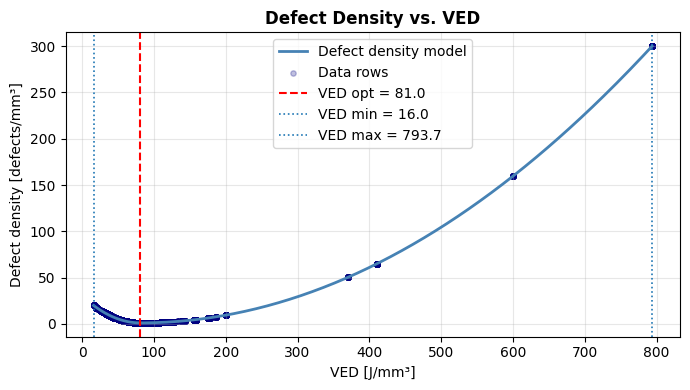

In [1217]:
VED_sweep = np.linspace(VED_min, VED_max, 300)
rho_sweep = defect_density_from_data_range(VED_sweep)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(VED_sweep, rho_sweep, color="steelblue", linewidth=2, label="Defect density model")
ax.scatter(df["VED_op"], df["defect_density"], color="navy", alpha=0.25, s=15, label="Data rows")

# add lines with min, max, optimum
ax.axvline(VED_opt, color="red", linestyle="--", linewidth=1.5, label=f"VED opt = {VED_opt:.1f}")
ax.axvline(VED_min, linestyle=":", linewidth=1.2, label=f"VED min = {VED_min:.1f}")
ax.axvline(VED_max, linestyle=":", linewidth=1.2, label=f"VED max = {VED_max:.1f}")

# labels, title
ax.set_title("Defect Density vs. VED", fontweight="bold")
ax.set_xlabel("VED [J/mm³]")
ax.set_ylabel("Defect density [defects/mm³]")

# grid, legend
ax.grid(alpha=0.3)
ax.legend()

# show and save
plt.tight_layout()
plt.savefig("database_ti_graphs/2_VED_defect_density_data_range.png", dpi=150)
plt.show()

# 2. Defects

In [1218]:
required_cols = ["VED_op", "V_gauge_mm3"]

df_defects = df.dropna(subset=required_cols).copy()

df_defects = df_defects[
    (df_defects["VED_op"] > 0) &
    (df_defects["V_gauge_mm3"] > 0)
].copy()

print(len(df_defects), "valid rows out of", len(df))

4557 valid rows out of 111009


In [1219]:
# expected number of defects
# n_expected = defect_density * V_gauge_mm3 [defects]
df_defects['n_expected'] = df_defects['defect_density'] * df_defects['V_gauge_mm3']
n_expected = df_defects['n_expected'].to_numpy(dtype=float)

# remove impossible/infinite values
df_defects = df_defects.replace([np.inf, -np.inf], np.nan)
df_defects = df_defects.dropna(subset=["VED_op"])
df_defects = df_defects[df_defects["VED_op"] > 0]

## 2.1. Defect Size Distribution

In [1220]:
rng = np.random.default_rng(42)

In [1221]:
# define function for the mean of ln(defect size) as a function of VED
def defect_mu(VED, VED_opt=81.0):
    mu_0 = np.log(50e-6)        # ln(50 micrometers) at optimal VED
    beta = 2e-6                 # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    return mu_0 + beta * (VED - VED_opt)**2

# define function for the std dev of ln(defect size) as a function of VED
def defect_sigma(VED, VED_opt=81.0):
    sigma_0 = 0.35
    gamma = 1e-5
    return sigma_0 + gamma * (VED - VED_opt)**2

# define function to generate defects
def generate_defects(n_defects, mu_ln, sigma_ln):
    return rng.lognormal(mu_ln, sigma_ln, n_defects)

### 2.1.a. Generate Defects
generate all defects for each specimen

In [1222]:
all_specimens = []
valid_indices = []

for idx, row in df_defects.iterrows():

    VED = row["VED_op"]
    V = row["V_gauge_mm3"]

    rho = defect_density_from_data_range(VED)
    n_expected = rho * V

    if not np.isfinite(n_expected) or n_expected <= 0:
        continue

    n_local = rng.poisson(n_expected)
    n_local = max(n_local, 1)

    mu_ln = defect_mu(VED, VED_opt)
    sigma_ln = defect_sigma(VED, VED_opt)

    defects = generate_defects(n_local, mu_ln, sigma_ln)

    all_specimens.append(defects)
    valid_indices.append(idx)

# len(all_specimens) == len(df) so it generating one defect population per specimen
print(len(all_specimens))
print(len(df_defects))

4557
4557


## 2.2. Max. Defects
Since only one defect is generated per specimen, this is taken as the max defect.

In [1223]:
# max defect per specimen [m]
max_defects_m = np.array([np.max(defects) for defects in all_specimens])
max_defects_m = max_defects_m[np.isfinite(max_defects_m)]

# convert for plotting/fitting readability
max_defects_um = max_defects_m * 1e6

### 2.2.a. GEV Distribution
Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

In [1224]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(max_defects_um)

x_gev = np.linspace(max_defects_um.min(), max_defects_um.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, loc=gev_loc, scale=gev_scale)

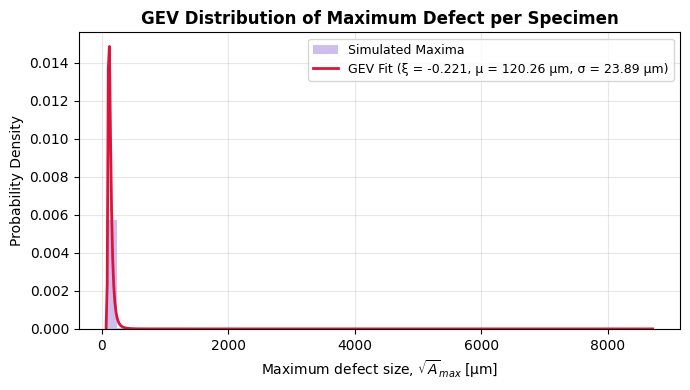

In [1225]:
# convert [sqrt(m)] to [sqrt(mm)]
conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(max_defects_um,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev,
        pdf_gev,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, μ = {gev_loc:.2f} µm, σ = {gev_scale:.2f} µm)")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect per Specimen", fontweight="bold")
ax.set_xlabel(r"Maximum defect size, $\sqrt{A}_{max}$ [µm]")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/2_GEV.png", dpi=150)
plt.show()

# 3. Fatigue-Life Statistics
Experimental fatigue lives and defect measurements from Zhou et al. (2025) are analyzed using the Paris law and the Shiozawa framework and reliability methods.

The resulting distributions captures the scatter from defect variability.

## 3.1. Paris & Shiozawa Formulas
functions for the working formulas are defined

### 3.1.a. Paris Law
Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [1226]:
# define function based on Paris law
def fatigue_life_paris(a_i, stress_a, C, m, Y, delta_sigma=None):
    if delta_sigma is None:      # fully reversed (R = -1)
        delta_sigma = 2.0 * stress_a
    
    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * np.pi**(m/2))

    Nf = paris_coeff * a_i**(1.0-(m/2.0))
    return Nf

def fatigue_life_paris_torch(a_i, stress_a, C, m, Y, delta_sigma=None):
    if delta_sigma is None:     # fully reversed loading, R = -1
        delta_sigma = 2.0 * stress_a

    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * torch.pi**(m / 2.0))

    Nf = paris_coeff * a_i**(1.0 - (m / 2.0))
    return Nf

#### 3.1.a.i. Paris Constants
use the database to fit *C* and *m*

In [1227]:
df_paris = df_defects.dropna(subset=["deltaK", "dadN"]).copy()

df_paris = df_paris[
    (df_paris["deltaK"] > 0) &
    (df_paris["dadN"] > 0)
]

print(len(df_paris))

log_dK = np.log10(df_paris["deltaK"])
log_dadN = np.log10(df_paris["dadN"])

m_fit, intercept = np.polyfit(log_dK, log_dadN, 1)

C_fit = 10**intercept

print(f"C = {C_fit:.4e}")
print(f"m = {m_fit:.4f}")


52
C = 1.7897e-11
m = 2.5534


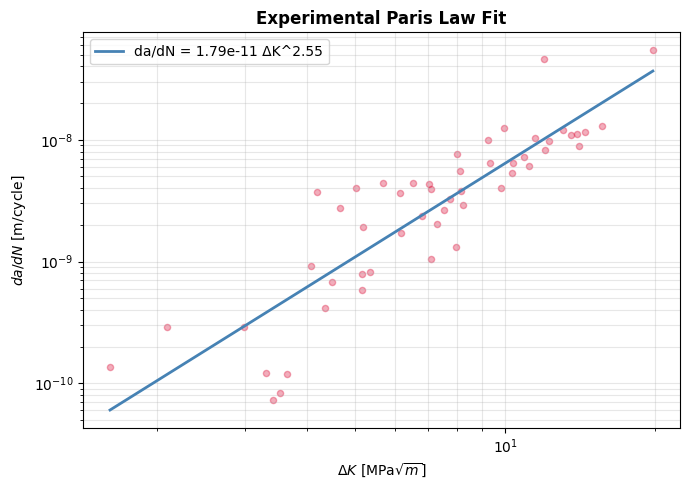

In [1228]:
x_line = np.logspace(log_dK.min(), log_dK.max(), 300)
y_line = C_fit * x_line**m_fit

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(df_paris["deltaK"], df_paris["dadN"],
           color="crimson", alpha=0.35, s=20)

ax.plot(x_line, y_line, color="steelblue", linewidth=2,
    label=f"da/dN = {C_fit:.2e} ΔK^{m_fit:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\Delta K$ [MPa$\sqrt{m}$]")
ax.set_ylabel(r"$da/dN$ [m/cycle]")

ax.set_title("Experimental Paris Law Fit", fontweight="bold")

ax.grid(alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.savefig("database_ti_graphs/3_paris_fit.png",dpi=150)
plt.show()

### 3.1.b. Stress Intensity Factor (SIF)
The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**ΔK_i = Y Δσ √(π a_i)**

where **a_i = sqrt(A)**

In the database, the SIF is given.

In [1229]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_a, defect_size):
    deltaK = Y * stress_a * np.sqrt(np.pi * defect_size)
    return deltaK

def stress_intensity_factor_torch(stress_a, defect_size):
    deltaK = Y * stress_a * torch.sqrt(torch.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 3.2. Experimental Fatigue-Life Statistics


In [1230]:
# from database
# pull columns into numpy arrays for modeling

# stress intensity factor, deltaK, [MPa*m^1/2]
deltaK = df_defects['deltaK'].to_numpy(dtype=float)

# crack growth rate [m/cycle]
dadN = df_defects['dadN'].to_numpy(dtype=float)
df_defects['dadN_um'] = df_defects['dadN']

# fatigue life, Nf [cycle]
Nf = df_defects['Nf'].to_numpy(dtype=float)                 

In [1231]:
# valid Paris-law rows
valid_paris = (
    np.isfinite(deltaK) & (deltaK > 0) &
    np.isfinite(dadN) & (dadN > 0)
)

# apply mask
deltaK_valid = deltaK[valid_paris]
dadN_valid = dadN[valid_paris]

print(len(deltaK_valid))

# log transform
log_dK = np.log10(deltaK_valid)
log_dadN = np.log10(dadN_valid)

52


In [1232]:
Nf = df_defects["Nf"].to_numpy(dtype=float)
stress_max = df_defects["stress_max"].to_numpy(dtype=float)

valid_life = (
    np.isfinite(Nf) & (Nf > 0) &
    np.isfinite(stress_max) & (stress_max > 0)
)

Nf_valid = Nf[valid_life]
stress_max_valid = stress_max[valid_life]

### 3.2.a. Reliability Curves

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 0.326, η = 2.593e+06
  B10 (10% failure) = 2.632e+03 cycles
  B50 (50% failure) = 8.439e+05 cycles


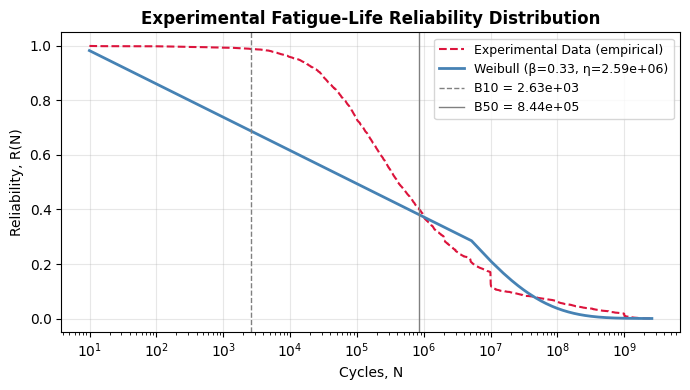

In [1233]:
lives_sorted = np.sort(Nf_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_valid, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Experimental Data (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")

# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Experimental Fatigue-Life Reliability Distribution",
             fontweight="bold")
ax.set_xlabel("Cycles, N")
ax.set_ylabel("Reliability, R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/3_reliability.png", dpi=150)
plt.show()

### 3.2.b. S-N Curves
experimental S-N curves

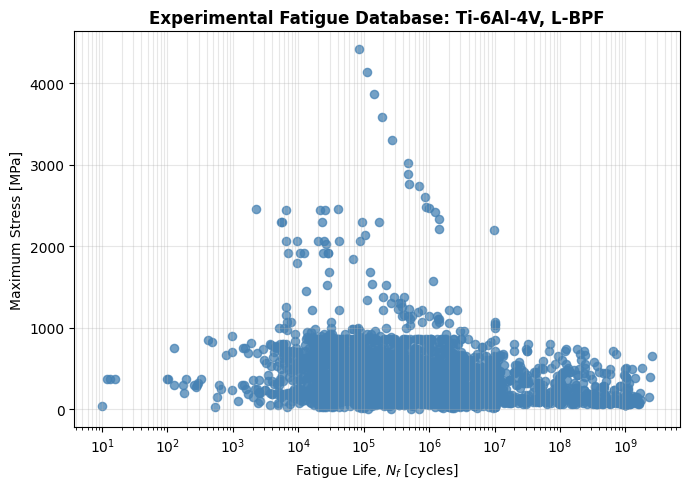

In [1234]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_valid,
           stress_max_valid.squeeze(),
           color="steelblue", alpha=0.75, s=35,
           label="Experimental Data")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue Life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress [MPa]")
ax.set_title("Experimental Fatigue Database: Ti-6Al-4V, L-BPF",
             fontweight="bold")

# grid, legend
ax.grid(alpha=0.3, which="both")
#ax.legend()

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/3_experimental_SN.png", dpi=150)
plt.show()

#### 3.2.b.i. PSN Curves
Binned percentiles are used to create a sort of probabilistic S-N curve.

In [1235]:
stress_exp = stress_max_valid.squeeze()
life_exp = Nf_valid

# create stress bins to store fatigue life data
stress_bins = np.array([200, 250, 300, 350, 400, 450])

bin_centers = []
B10 = []
B50 = []
B90 = []

for i in range(len(stress_bins) - 1):
    mask = (stress_exp >= stress_bins[i]) & (stress_exp < stress_bins[i+1])
    lives_bin = life_exp[mask]

    if len(lives_bin) < 3:
        continue

    bin_centers.append(0.5 * (stress_bins[i] + stress_bins[i+1]))
    B10.append(np.quantile(lives_bin, 0.10))
    B50.append(np.quantile(lives_bin, 0.50))
    B90.append(np.quantile(lives_bin, 0.90))

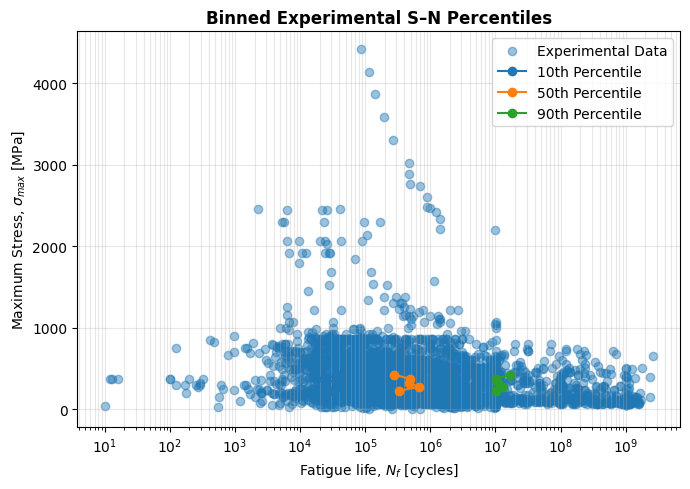

In [1236]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(life_exp, stress_exp, alpha=0.45, label="Experimental Data")

# add probabilities of failure
ax.plot(B10, bin_centers, marker="o", label="10th Percentile")
ax.plot(B50, bin_centers, marker="o", label="50th Percentile")
ax.plot(B90, bin_centers, marker="o", label="90th Percentile")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress, $\sigma_{max}$ [MPa]")
ax.set_title("Binned Experimental S–N Percentiles",
             fontweight="bold")

# legend, grid
ax.grid(alpha=0.3, which="both")
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/3_experimental_SN_percentiles.png", dpi=150)
plt.show()

### 3.2.a. Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:
(N/√A) ∝ (deltaK_i)^(-m)
log(deltaK_i) = -(1/m)*log(N/√A) + C
→ **slope = -1/m**

In [1237]:
# initial crack/defect size from generated max defects
a_i = max_defects_m

# align df_defects to the generated valid_indices
df_model = df_defects.loc[valid_indices].copy()

Nf = df_model["Nf"].to_numpy(dtype=float)
stress_max = df_model["stress_max"].to_numpy(dtype=float)
stress_min = df_model["stress_min"].to_numpy(dtype=float)

delta_sigma = stress_max - stress_min
Y_arr = np.full_like(delta_sigma, 0.5)  # assuming internal defects

dKi = delta_K_initial(a_i, delta_sigma, Y_arr)

Nnorm_samples = Nf / a_i

valid_mc = (
    np.isfinite(a_i) & (a_i > 0) &
    np.isfinite(Nf) & (Nf > 0) &
    np.isfinite(dKi) & (dKi > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0) &
    np.isfinite(stress_max) & (stress_max > 0) &
    np.isfinite(stress_min)
)

a_i_valid = a_i[valid_mc]
Nf_valid = Nf[valid_mc]
dKi_samples_valid = dKi[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]
stress_max_valid = stress_max[valid_mc]
stress_min_valid = stress_min[valid_mc]
delta_sigma_valid = delta_sigma[valid_mc]
Y_valid_np = Y_arr[valid_mc]

In [1238]:
# Nnorm_samples = Nf / a_i   # [cycles/m]
# df_defects['Nnorm_samples'] = df_defects['Nf'] / df_defects['a_i']

In [1239]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid)   #.flatten()
log_dKi = np.log10(dKi_samples_valid)       #.flatten()

In [1240]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = -1.0 / m_Ti

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

In [1241]:

# stress_min_valid = torch.tensor(stress_min.to_numpy(dtype=float)[valid_mc],
#                                 dtype=torch.float32
#                                 ).unsqueeze(1)
# Y_valid = torch.tensor(Y_valid_np, dtype=torch.float32).unsqueeze(1)
# Y_valid_np = torch.tensor(df["Y"].to_numpy(dtype=float)[valid_mc],
#                        dtype=torch.float32).unsqueeze(1)
    #Y[valid_mc], dtype=torch.float32).unsqueeze(1)
# stress_max_valid = torch.tensor(df["stress_max"].to_numpy(dtype=float)[valid_mc],
#                                 dtype=torch.float32).unsqueeze(1)

delta_sigma_valid = stress_max_valid - stress_min_valid
stress_a_valid = delta_sigma_valid / 2

Shiozawa log-log fit: slope = -0.0803
Expected from Paris (m=2.56492): slope = -0.3899


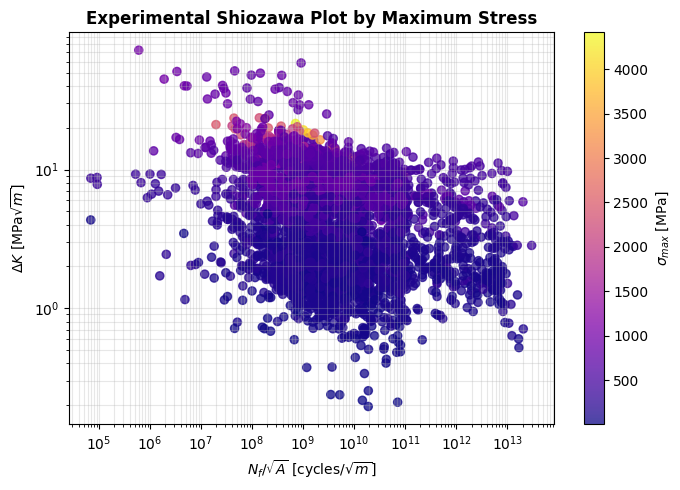

In [1242]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(Nnorm_samples_valid, dKi_samples_valid,
    c=stress_max_valid.squeeze(),
    cmap="plasma", alpha=0.75, s=35)

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="grey", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log scale
ax.set_xscale("log")
ax.set_yscale("log")

# label, titles
ax.set_xlabel(r"$N_f/\sqrt{A}$ [cycles/$\sqrt{m}$]")
ax.set_ylabel(r"$\Delta K$ [MPa$\sqrt{m}$]")
ax.set_title(r"Experimental Shiozawa Plot by Maximum Stress",
             fontweight="bold")

# legend, colobar, grid
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\sigma_{max}$ [MPa]")
ax.grid(alpha=0.3, which="both")

print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m_Ti}): slope = {expected_slope:.4f}")

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/3_shiozawa_experimental_stress.png", dpi=150)
plt.show()

# 4. PINN

In [1243]:
# reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [1244]:
# convert data to tensors for plotting and PINN
a_tensor = torch.tensor(a_i_valid, dtype=torch.float32).unsqueeze(1)  # input = max defect / initial crack size
Nf_tensor = torch.tensor(Nf_valid, dtype=torch.float32).unsqueeze(1)  # output = fatigue life
stress_max_tensor = torch.tensor(stress_max_valid, dtype=torch.float32).unsqueeze(1)
stress_min_tensor = torch.tensor(stress_min_valid, dtype=torch.float32).unsqueeze(1)
delta_sigma_tensor = torch.tensor(delta_sigma_valid, dtype=torch.float32).unsqueeze(1)
stress_a_tensor = delta_sigma_tensor / 2
Y_tensor = torch.tensor(Y_valid_np, dtype=torch.float32).unsqueeze(1)

## 4.0. Baseline Predictions

In [1245]:
# Paris-law baseline prediction
Nf_paris = fatigue_life_paris(
    a_i_valid,
    stress_a_valid.squeeze(),
    C_Ti,
    m_Ti,
    Y_valid_np.squeeze(),
    delta_sigma_valid.squeeze()
)

# log-space RMSE
log_rmse_paris = np.sqrt(
    np.mean(
        (
            np.log(Nf_paris)
            - np.log(Nf_valid)
        )**2
    )
)

# physical RMSE
rmse_paris = np.sqrt(
    np.mean(
        (
            Nf_paris
            - Nf_valid
        )**2
    )
)

print(f"Paris RMSE = {rmse_paris:.3e}")
print(f"Paris Log-RMSE = {log_rmse_paris:.4f}")

Paris RMSE = 1.876e+08
Paris Log-RMSE = 3.2434


### 4.0.a. Baseline Plot

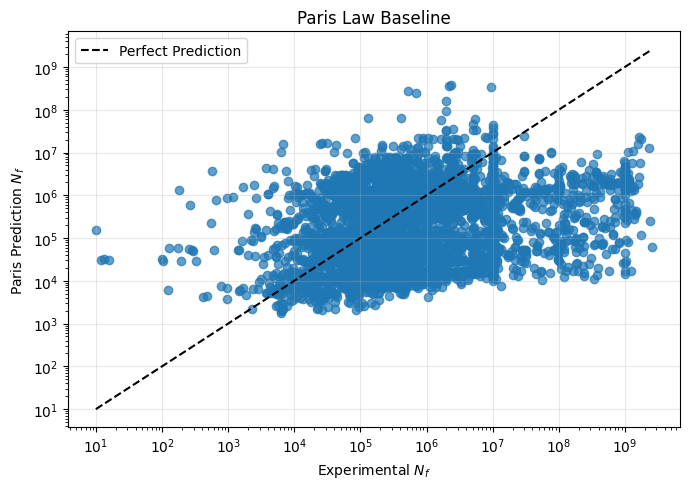

In [1246]:
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(Nf_valid, Nf_paris, alpha=0.7)

min_val = min(Nf_valid.min(), Nf_paris.min())
max_val = max(Nf_valid.max(), Nf_paris.max())

ax.plot([min_val, max_val], [min_val, max_val],
        "k--", label="Perfect Prediction")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Experimental $N_f$")
ax.set_ylabel("Paris Prediction $N_f$")
ax.set_title("Paris Law Baseline")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("database_ti_graphs/4_baseline_predictions.png", dpi=150)
plt.show()

The Paris baseline plot is *much worse* than the PINN. The baseline shows huge compression and little sensitivity to large-life specimens. The PINN, on the other hand, for **Feature Set B = [log(a_i), log(stress_max), Y, log(VED)]**, captures much more spread and follows the diagonal trend.

The PINN, therefore, significantly improves predictive accuracy relative to a pure Paris-law fatigue-life model by incorporating process and defect information learned from the database.

## 4.1. Train/Test Split
Data is split into 70% training, 30% test as in Zhou et al. (2025).

A different set of inputs can be chosen to test the model:

**Model A: physics-only-ish**
[log(a_i), log(stress_max), Y]

**Model B: add process**
[log(a_i), log(stress_max), Y, log(VED_op)]

**Model C: add loading**
[log(a_i), log(stress_max), log(delta_sigma), Y, log(VED_op), r_ratio, log(frequency)]

**Model D: add material/mechanical**
[previous + Kt, E_gpa, yield_strength, uts, elongation]

### 4.1.a. Define Data

In [1247]:
feature_df = df_model.loc[valid_mc].copy()

# choose feature set
feature_set = "D"   # A, B, C, or D

base_features = {
    "log_a_i": np.log(a_i_valid),
    "log_stress_max": np.log(stress_max_valid),
    "Y": Y_valid_np,
}

process_features = {
    "log_VED": np.log(feature_df["VED_op"].to_numpy(dtype=float)),
}

loading_features = {
    "log_delta_sigma": np.log(delta_sigma_valid),
    "r_ratio": feature_df["r_ratio"].to_numpy(dtype=float),
    "log_frequency": np.log(feature_df["frequency_hz"].to_numpy(dtype=float)),
}

material_features = {
    "Kt": feature_df["Kt"].to_numpy(dtype=float),
    "E_gpa": feature_df["E_gpa"].to_numpy(dtype=float),
    "yield_strength": feature_df["yield_strength"].to_numpy(dtype=float),
    "uts": feature_df["uts"].to_numpy(dtype=float),
    "elongation": feature_df["elongation"].to_numpy(dtype=float),
}

if feature_set == "A":
    selected = base_features

elif feature_set == "B":
    selected = {**base_features, **process_features}

elif feature_set == "C":
    selected = {**base_features, **process_features, **loading_features}

elif feature_set == "D":
    selected = {**base_features, **process_features, **loading_features, **material_features}

In [1248]:
# make dataframe so we can drop bad rows cleanly
X_df = pd.DataFrame(selected)
X_df["log_Nf"] = np.log(Nf_valid)

X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna()
kept_idx = X_df.index.to_numpy()

feature_names = [c for c in X_df.columns if c != "log_Nf"]

X_all = torch.tensor(X_df[feature_names].to_numpy(), dtype=torch.float32)
y_all = torch.tensor(X_df[["log_Nf"]].to_numpy(), dtype=torch.float32)

input_dim = X_all.shape[1]

print("Using features:", feature_names)
print("Input dimension:", input_dim)
print("Samples:", X_all.shape[0])

Using features: ['log_a_i', 'log_stress_max', 'Y', 'log_VED', 'log_delta_sigma', 'r_ratio', 'log_frequency', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']
Input dimension: 12
Samples: 598


In [1249]:
# physical fatigue lives
Nf_phys_all = torch.tensor(
    X_df["log_Nf"].apply(np.exp).to_numpy(),
    dtype=torch.float32
).unsqueeze(1)

In [1250]:
# build the physics tensors using those same rows
a_phys_all = torch.tensor(a_i_valid[kept_idx], dtype=torch.float32).unsqueeze(1)
stress_a_phys_all = torch.tensor(stress_a_valid[kept_idx], dtype=torch.float32).unsqueeze(1)
delta_sigma_phys_all = torch.tensor(delta_sigma_valid[kept_idx], dtype=torch.float32).unsqueeze(1)
Y_phys_all = torch.tensor(Y_valid_np[kept_idx], dtype=torch.float32).unsqueeze(1)

### 4.1.b. Train/Test Split

In [1251]:
n = X_all.shape[0]
perm = torch.randperm(n)

n_train = int(0.70 * n)

train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_train = X_all[train_idx]
X_test = X_all[test_idx]

y_train = y_all[train_idx]
y_test = y_all[test_idx]

# normalize from train only
X_mean = X_train.mean(dim=0, keepdim=True)
X_std = X_train.std(dim=0, keepdim=True)
X_std[X_std == 0] = 1.0

y_mean = y_train.mean()
y_std = y_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

In [1252]:
# split physics tensors
a_train = a_phys_all[train_idx]
a_test = a_phys_all[test_idx]

stress_a_train = stress_a_phys_all[train_idx]
stress_a_test = stress_a_phys_all[test_idx]

delta_sigma_train = delta_sigma_phys_all[train_idx]
delta_sigma_test = delta_sigma_phys_all[test_idx]

Y_train = Y_phys_all[train_idx]
Y_test = Y_phys_all[test_idx]

In [1253]:
Nf_train = Nf_phys_all[train_idx]
Nf_test = Nf_phys_all[test_idx]

## 4.2. Define PINN

In [1254]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            
            # first hidden layer
            # nn.Linear(3, 64),         # (input (3), output)
            nn.Linear(input_dim, 64),   # input = homwever many inputs
            nn.Tanh(),
            
            # second hidden layer
            nn.Linear(64, 64),
            nn.Tanh(),

            # output = 1 number (N), since we want to predict a single fatigue life value for each input N/√A
            nn.Linear(64, 1) 
        )

    # forward method defines how input data flows through the network
    def forward(self, X):
        # log_Nf_scaled = self.net(X) # predicts scaled log(Nf)

        # # convert back to physical fatigue life
        # log_Nf = log_Nf_scaled * log_Nf_std + log_Nf_mean
        # Nf = torch.exp(log_Nf)        # makes prediction physical and positive
        
        # # predicts scaled log(Nf)
        return self.net(X)

PINN Architecture from Liao et al. (2025):
- 2 hidden layers 
- 64 neurons each 
- Tanh activation function

Liao et al. (2025). A physics-informed neural network method for identifying parameters and predicting remaining life of fatigue crack growth International. Journal of Fatigue, 191, 108678. https://doi.org/10.1016/j.ijfatigue.2024.108678.

### 4.2.a. Early Stopping
Implement **early stopping** on the model to monitor a **validation metric**, to monitor whether the model is still improving on the validation data on each epoch.

In [1255]:
class EarlyStopping:
    def __init__(self, patience=150, min_delta=1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True

### 4.2.b. History Plots

In [1256]:
# define a function to plot the history graphs
def plot_history(train_metric,
                 val_metric=None,
                 metric_name="Loss",
                 log_scale=False):
    
    fig, ax = plt.subplots(figsize=(7,4))

    ax.plot(train_metric, label=f"Train: {metric_name}")

    # validation metric
    if val_metric is not None:
        ax.plot(val_metric,
                 label=f"Val: {metric_name}")

    # axis labels
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} History", fontweight="bold")

    # log scale if necessayr
    if log_scale:
        ax.set_yscale("log")

    # legend, grig
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    
    # save and show
    filename = metric_name.lower().replace(" ", "_")
    fig.savefig(f"database_ti_graphs/4_val_{filename}.png", dpi=150)
    plt.show()

## 4.3. Define Losses
In general, **Total Loss = Data Loss + Physics Loss** where the losses are given by the **mean squared errors (MSE)**.

### 4.3.a. Physics Loss: Paris Law

In [1257]:
# define a function to enforce the Paris Law
# everything in physics_loss must be torch operations to allow autograd to compute gradients
def physics_loss(model, X_scaled, a_physical, stress_a, C, m, Y, delta_sigma, y_mean, y_std):
    log_Nf_pred_scaled = model(X_scaled)
    log_Nf_pred = (log_Nf_pred_scaled * y_std + y_mean)

    Nf_physics = fatigue_life_paris_torch(a_physical, stress_a, C, m, Y, delta_sigma)

    # convert to log space
    log_Nf_physics = torch.log(Nf_physics)

    return torch.mean((log_Nf_pred - log_Nf_physics)**2)

### 4.3.b. Data Loss

In [1258]:
# define a function to compute the data loss

# # log-MSE between predicted and true defect sizes
# def data_loss_logMSE(model, X_scaled, y_scaled):
#     y_pred_scaled = model(X_scaled)
#     return torch.mean((torch.log(y_pred_scaled) - torch.log(y_scaled))**2)

# MSE between predicted and true defect sizes
def data_loss_MSE(model, X_scaled, y_scaled):
    y_pred_scaled = model(X_scaled)
    return torch.mean((y_pred_scaled - y_scaled)**2)

Liao et al. (2025) uses 𝐿𝑜𝑠𝑠_𝐷 = 𝑀𝑆𝐸(𝑛_𝑝𝑟𝑒𝑑, 𝑛_𝑜𝑏𝑠) as the data loss function.

## 4.4. Training

In [1259]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000
early_stopping = EarlyStopping(patience=150, min_delta=1e-6)

loss_history = []
physics_loss_history = []
data_loss_history = []
val_loss_history = []
train_rmse_history = []
test_rmse_history = []

# weights
w_d_liao = 100.0    # weight for data loss, from Liao et al. (2025)
w_p_liao = 1.0      # weight for physics loss, from Liao et al. (2025)
w_d = 1.0           # weight for data loss
w_p = 0.001          # weight for physics loss

# train for many iterations (epochs)
for epoch in range(epochs):
    
    # training
    model.train()
    optimizer.zero_grad()       # reset gradients before backprop

    y_pred_train = model(X_train_scaled)

    # define losses
    loss_d = data_loss_MSE(model, X_train_scaled, y_train_scaled)
    loss_p = physics_loss(model, X_train_scaled, a_train,
                          stress_a_train, C_Ti, m_Ti, Y_train,
                          delta_sigma_train, y_mean, y_std)

    # weighted total loss
    loss = (w_d_liao * loss_d) + (w_p_liao * loss_p)
    #loss = (w_d * loss_d) + (w_p * loss_p)

    loss.backward()             # backpropagation: computes gradients of all parameters
    optimizer.step()            # updates network weights

    # validation / test loss
    model.eval()
    with torch.no_grad():
        val_data_loss = data_loss_MSE(model, X_test_scaled, y_test_scaled)

        train_pred = model(X_train_scaled)
        train_rmse = torch.sqrt(torch.mean((train_pred - y_train_scaled)**2))

        test_pred = model(X_test_scaled)
        test_rmse = torch.sqrt(
        torch.mean((test_pred - y_test_scaled)**2))

    # early stopping checks validation data loss
    early_stopping(val_data_loss.item(), model)

    # save histories
    loss_history.append(loss.item())
    physics_loss_history.append(loss_p.item())
    data_loss_history.append(loss_d.item())
    train_rmse_history.append(train_rmse.item())
    test_rmse_history.append(test_rmse.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_d.item():.4e} | "
            f"Physics: {loss_p.item():.4e} | "
            f"Val: {val_data_loss.item():.4e}"
        )

    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break

# restore best validation model
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

Epoch     0 | Total: 1.0777e+02 | Data: 1.0343e+00 | Physics: 4.3427e+00 | Val: 8.2030e-01
Early stopping at epoch 494


*For weights (lambda_d = 100, lambda_p = 1), of first implementation*: Liao et al. (2025).

### 4.4.a. Plot Accuracy
use RMSE history to show accuracy

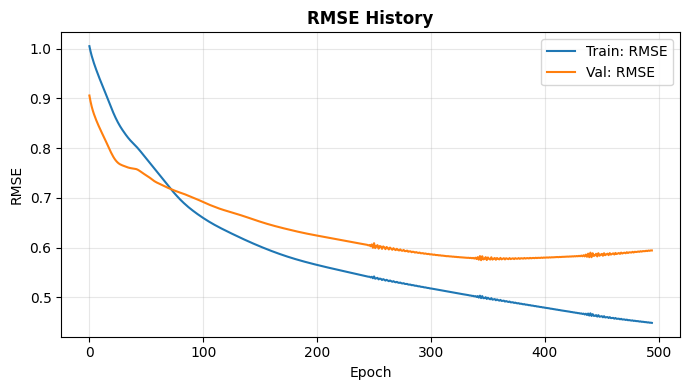

In [1260]:
plot_history(train_metric=train_rmse_history,
             val_metric=test_rmse_history,
             metric_name="RMSE",
             log_scale=False)

For **Feature Set B = [log(a_i), log(stress_max), Y, log(VED)]**: The train RMSE reduces from 0.96 to 0.66 and the validation RMSE reduces from 0.96 to 0.91 then slowly increases again. This is classic *overfitting*. So the early stopping is too patient--it needs to stop sooner.

**Patience reduced**: patience = 500 to patience = 300

For **Feature Set C = [log(a_i), log(stress_max), log(delta_sigma), Y, log(VED_op), r_ratio, log(frequency)]**: Validation RMSE reaches 0.69-0.7, which is an improvement from B. The issue remains: train RMSE keeps decreasing, while validation RMSE reaches a minimum, then rises. Patience should be reduced again. Reducing patience to 150 seems to fix this issue.

**Patience reduced**: patience = 300 to patience = 150

For **Feature Set D = [previous + Kt, E_gpa, yield_strength, uts, elongation]**: From the validation RMSE, generalization is substantially improved from B, about 16% (minRMSE from C = 0.69, minRMSE from D = 0.58).

## 4.5. Predictions

In [1261]:
model.eval()

with torch.no_grad():
    y_pred_train_scaled = model(X_train_scaled)
    y_pred_test_scaled  = model(X_test_scaled)

    # unscale back to log(Nf)
    log_Nf_pred_train = y_pred_train_scaled * y_std + y_mean
    log_Nf_pred_test  = y_pred_test_scaled  * y_std + y_mean

    # convert log(Nf) back to physical cycles
    Nf_pred_train = torch.exp(log_Nf_pred_train).numpy()
    Nf_pred_test  = torch.exp(log_Nf_pred_test).numpy()

a_np = a_tensor.numpy()
Nf_train_np = Nf_train.numpy()
Nf_test_np  = Nf_test.numpy()

### 4.5.a. Evaluation

In [1262]:
# prediction errors
errors_test = Nf_pred_test - Nf_test_np

mse_test = np.mean(errors_test**2)        # mean squared error
rmse_test = np.sqrt(mse_test)             # root mean squared error
mae_test = np.mean(np.abs(errors_test))   # mean absolute error

# log-space errors
log_errors_test = np.log(Nf_pred_test) - np.log(Nf_test_np)

log_mse_test = np.mean(log_errors_test**2)
log_rmse_test = np.sqrt(log_mse_test)
log_mae_test = np.mean(np.abs(log_errors_test))

# print results table
print(f"{'Metric':<10} {'Value':>14} {'Log Value':>14}")
print("-" * 42)

print(f"{'MSE':<10} {mse_test:>14.4e} {log_mse_test:>14.4e}")
print(f"{'RMSE':<10} {rmse_test:>14.4e} {log_rmse_test:>14.4e}")
print(f"{'MAE':<10} {mae_test:>14.4e} {log_mae_test:>14.4e}")

Metric              Value      Log Value
------------------------------------------
MSE            2.4270e+13     1.4340e+00
RMSE           4.9265e+06     1.1975e+00
MAE            1.7153e+06     9.1204e-01


### 4.5.b. Accuracy Plots

#### 4.5.b.i. Training History Plots

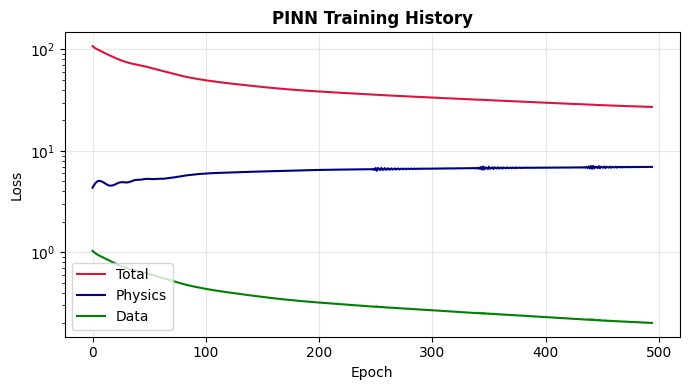

In [1263]:
# plot training history
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(loss_history, color="crimson", label="Total")
ax.plot(physics_loss_history, color="navy", label="Physics")
ax.plot(data_loss_history, color="green", label="Data")

# log scale
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN Training History", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/4_PINN_loss_history.png", dpi=150)
plt.show()

For **Feature Set B = [log(a_i), log(stress_max), Y, log(VED)]**: Physics loss is still losing: it moves from around 3 to 6, while the data loss decreses from approximately 0.9 to 0.4. The optimizer is choosing to fit the data and ignore the Paris lawas in the Zhou dataset. The network is finding patterns that explain fatigue life better than the Paris baseline.

For **Feature Set C = [log(a_i), log(stress_max), log(delta_sigma), Y, log(VED_op), r_ratio, log(frequency)]**: Physics loss still rises, so same conclusion as B. The data-informed part of the PINN is learning useful fatigue-life structure, while the Paris-law penalty remains partially inconsistent with the database.

For **Feature Set D = [previous + Kt, E_gpa, yield_strength, uts, elongation]**: Again, the physics loss is about 4 to 7, and the data loss is about 1.0 to 0.2. **The network still prefers data.** This is a consistent conclusion.

#### 4.4.b.ii. Predicted vs. True Defect Sizes

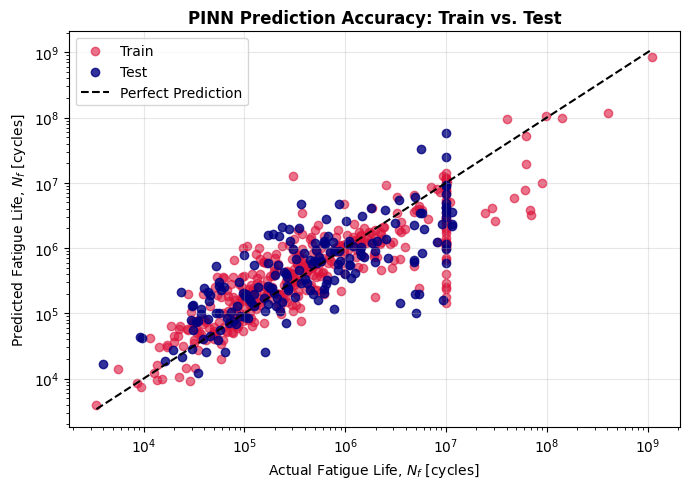

In [1264]:
# plot predicted vs. true defect sizes
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_train_np, Nf_pred_train,
           color="crimson",
           alpha=0.6, label="Train")
ax.scatter(Nf_test_np, Nf_pred_test,
           color="navy",
           alpha=0.8, label="Test")

min_val = min(Nf_train_np.min(), Nf_test_np.min(), Nf_pred_train.min(), Nf_pred_test.min())
max_val = max(Nf_train_np.max(), Nf_test_np.max(), Nf_pred_train.max(), Nf_pred_test.max())

ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", label="Perfect Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel(r"Actual Fatigue Life, $N_f$ [cycles]")
ax.set_ylabel(r"Predicted Fatigue Life, $N_f$ [cycles]")
ax.set_title("PINN Prediction Accuracy: Train vs. Test", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("database_ti_graphs/4_PINN_accuracy_train_vs_test.png", dpi=150)
plt.show()

For **Feature Set B = [log(a_i), log(stress_max), Y, log(VED)]**: The PINN predictions span roughly 10^4 to 10^9 cycles. and follow the diagonal. So, defect size, stress, and VED are contributing useful information. The network is no longer simply regressing toward the mean.

For **Feature Set C = [log(a_i), log(stress_max), log(delta_sigma), Y, log(VED_op), r_ratio, log(frequency)]**: Predictions follow the diagonal much more strongly. The train/test overlap is still good. The extreme compression is mostly gone.

For **Feature Set D = [previous + Kt, E_gpa, yield_strength, uts, elongation]**: This plot shows less scatter, a tighter cluster around the diagonal, a good mix of train and test values, improvements amongst low- and high-life predistions.

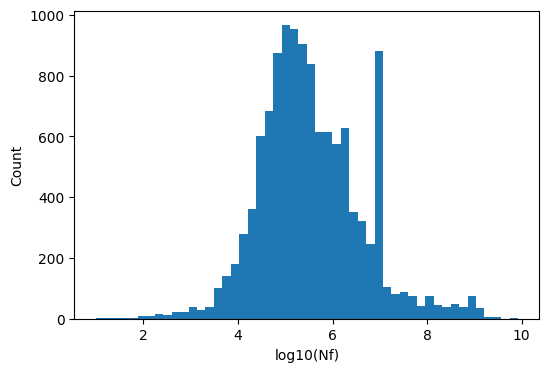

In [1270]:
plt.figure(figsize=(6,4))
plt.hist(np.log10(df["Nf"]), bins=50)
plt.xlabel("log10(Nf)")
plt.ylabel("Count")
plt.show()

The histogram counts the number of specimens per fatigue life. This explains the large number of specimens with a fatigue life of 10^7, seen as band in the predicted vs actual lives plot.

### 4.5.c. Crack Growth Curve
Plot fatigue life vs. initial defect size for train and test data

In [1265]:
# convert tensors to 1D numpy arrays
a_train_np = a_train.detach().cpu().numpy().squeeze()
a_test_np  = a_test.detach().cpu().numpy().squeeze()

Nf_train_np = Nf_train.detach().cpu().numpy().squeeze()
Nf_test_np  = Nf_test.detach().cpu().numpy().squeeze()

Nf_pred_train_np = Nf_pred_train.squeeze()
Nf_pred_test_np  = Nf_pred_test.squeeze()

# sort train data by crack size
train_sort_idx = np.argsort(a_train_np)
a_train_sorted = a_train_np[train_sort_idx]
Nf_train_sorted = Nf_train_np[train_sort_idx]
Nf_pred_train_sorted = Nf_pred_train_np[train_sort_idx]

# sort test data by crack size
test_sort_idx = np.argsort(a_test_np)
a_test_sorted = a_test_np[test_sort_idx]
Nf_test_sorted = Nf_test_np[test_sort_idx]
Nf_pred_test_sorted = Nf_pred_test_np[test_sort_idx]

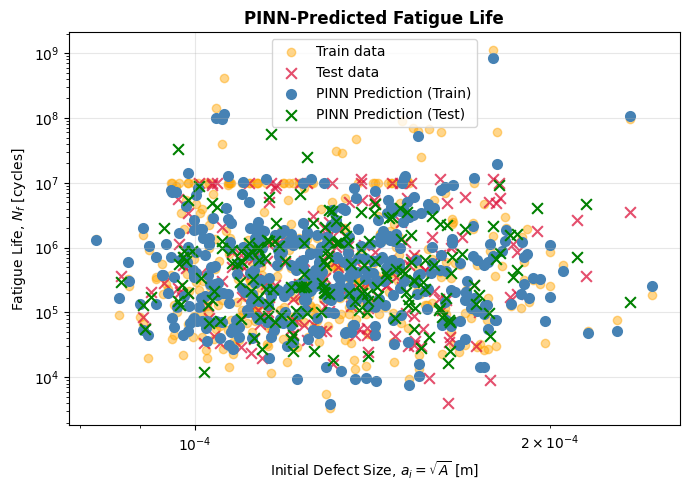

In [1266]:
fig, ax = plt.subplots(figsize=(7, 5))

# true experimental data
ax.scatter(a_train_sorted, Nf_train_sorted,
           color="orange",
           alpha=0.45, label="Train data")

ax.scatter(a_test_sorted, Nf_test_sorted,
           color="crimson", marker="x", s=60,
           alpha=0.75, label="Test data")

# model predictions
ax.scatter(a_train_sorted, Nf_pred_train_sorted,
           color="steelblue",
           linewidth=2, label="PINN Prediction (Train)")

ax.scatter(a_test_sorted, Nf_pred_test_sorted,
           color="green", marker="x", 
           s=60, label="PINN Prediction (Test)")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# labels, title
ax.set_xlabel(r"Initial Defect Size, $a_i = \sqrt{A}$ [m]")
ax.set_ylabel(r"Fatigue Life, $N_f$ [cycles]")
ax.set_title("PINN-Predicted Fatigue Life", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("database_ti_graphs/4_PINN_life_vs_defect.png", dpi=150)
plt.show()

For **Feature Set B = [log(a_i), log(stress_max), Y, log(VED)]**: The vertical bands show a_i is not varying much and most generated defects lie around 10^-4 m with a relatively small spread. Meanwhile, Nf spans about 8 orders of magnitude. This suggests defect size alone cannot explain the fatigue-life scatter in this database, confirming adding VED helped.

For **Feature Set C = [log(a_i), log(stress_max), log(delta_sigma), Y, log(VED_op), r_ratio, log(frequency)]**: Same conclusions as B since the points are clustered around 10^4 m.

# 5. Correlation Analysis
A correlation analysis is done to test the parameters in the Zhou data to investigate what next steps should be taken.

## 5.1. Correlation Matrix

In [1267]:
# create dataframe for correlation analysis
corr_df = pd.DataFrame({
    "log_a_i": np.log10(a_i_valid),
    "log_stress_max": np.log10(
        stress_max_valid.detach().numpy().squeeze()
    ),
    "Y": Y_valid_np.detach().numpy().squeeze(),
    "log_Nf": np.log10(Nf_valid)
})

# correlation matrix
corr = corr_df.corr()

print(corr.round(3))

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

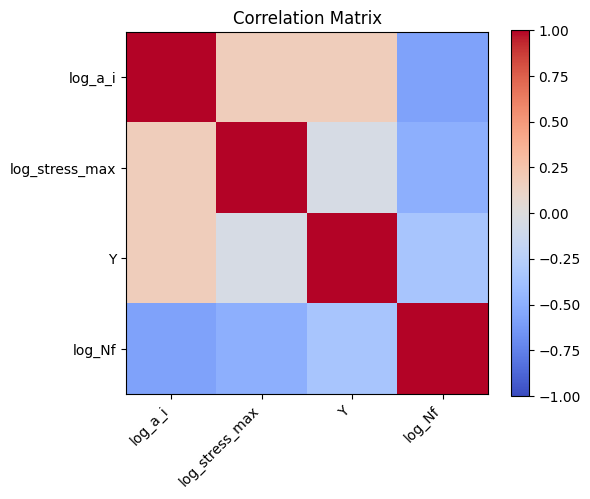

In [ ]:
# plot
fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(im)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

ax.set_title("Correlation Matrix")

plt.tight_layout()
fig.savefig("database_ti_graphs/5_corr_matrix.png", dpi=150)
plt.show()

The correlation between log_stress_max and log_Nf is ~-0.45, and the correlation between log_a_i and log_Nf is ~-0.55. So, both **defect size** and **stress** matter for this data.

## 5.2. Linear Regression
A linear regression model is created with the same variables and transforms as the PINN to ensure correlation.

**log(Nf)​ = β_0 + (β_1 * ​log(a_i))​ + (β_2 * ​log(stress_max))​ + (β_3 * ​Y)**

In [ ]:
# inputs
X_lin = np.column_stack([
    np.log(a_i_valid),
    np.log(stress_max_valid.detach().numpy().squeeze()),
    Y_valid_np.detach().numpy().squeeze()
])

# target
y_lin = np.log(Nf_valid)

# train/test split using same indices as PINN
X_train_lin = X_lin[train_idx.numpy()]
X_test_lin  = X_lin[test_idx.numpy()]

y_train_lin = y_lin[train_idx.numpy()]
y_test_lin  = y_lin[test_idx.numpy()]

# fit model
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

# predictions
y_pred_train_lin = lin_model.predict(X_train_lin)
y_pred_test_lin  = lin_model.predict(X_test_lin)

# convert back to cycles
Nf_pred_train_lin = np.exp(y_pred_train_lin)
Nf_pred_test_lin  = np.exp(y_pred_test_lin)

# metrics
rmse_train = np.sqrt(
    mean_squared_error(
        np.exp(y_train_lin),
        Nf_pred_train_lin
    )
)

rmse_test = np.sqrt(
    mean_squared_error(
        np.exp(y_test_lin),
        Nf_pred_test_lin
    )
)

r2_train = r2_score(y_train_lin, y_pred_train_lin)
r2_test = r2_score(y_test_lin, y_pred_test_lin)

In [ ]:
print("\nLinear Regression Results")
print("-"*40)
print(f"Train RMSE = {rmse_train:.3e}")
print(f"Test RMSE  = {rmse_test:.3e}")
print(f"Train R²   = {r2_train:.4f}")
print(f"Test R²    = {r2_test:.4f}")

print("\nCoefficients")
print(f"Intercept      = {lin_model.intercept_:.4f}")
print(f"log(a_i)       = {lin_model.coef_[0]:.4f}")
print(f"log(stress)    = {lin_model.coef_[1]:.4f}")
print(f"Y              = {lin_model.coef_[2]:.4f}")

exp_coeff_log_a_i = 1 - (m/2)

# expected coeff. for log(a_i) from Paris/Shiozawa
print(f"\nExpected Coeff. for log(a_i): {exp_coeff_log_a_i:.4f}")
print(f"Regression Coeff. for log(a_i): {lin_model.coef_[0]:.4f}")


Linear Regression Results
----------------------------------------
Train RMSE = 2.319e+05
Test RMSE  = 2.403e+05
Train R²   = 0.6025
Test R²    = 0.3430

Coefficients
Intercept      = 74.0679
log(a_i)       = -0.4309
log(stress)    = -9.5491
Y              = -4.8955

Expected Coeff. for log(a_i): -0.2825
Regression Coeff. for log(a_i): -0.4309


The expected coeff. and the regression coeff. may not be exactly because
- the Shiozawa approximation, a_f >> a_i, which dros the final crack size term, may not be exactly correct
- the Zhou data contains more variable info hidden in the fatigue life number
- the chosen *m* value may not represent all the data (unlikely the biggest problem since values are so close)

Since these values are not wildly different, the data is not suggesting the Paris law is incorrect.

--> The optimizer is trying to satisfy both m values of *m* as shown in the training history.

# Appendix

### 2.1.a. VED-Relative Density Correlation
An **empirical approximation** curve relates VED to relative density. This relationship should be treated as illustrative.

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

In [ ]:
# define VED-relative density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative density (normalized to 1 at optimal VED)

k = 0.05              # steepness of VED curve

## 6.3. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

Shiozawa collapse fit: slope = -0.4232
Expected from Paris (m=2.56492): slope = -0.1667


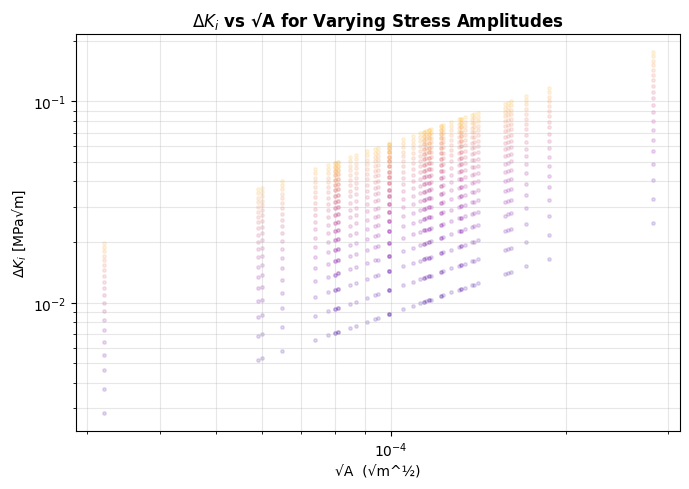

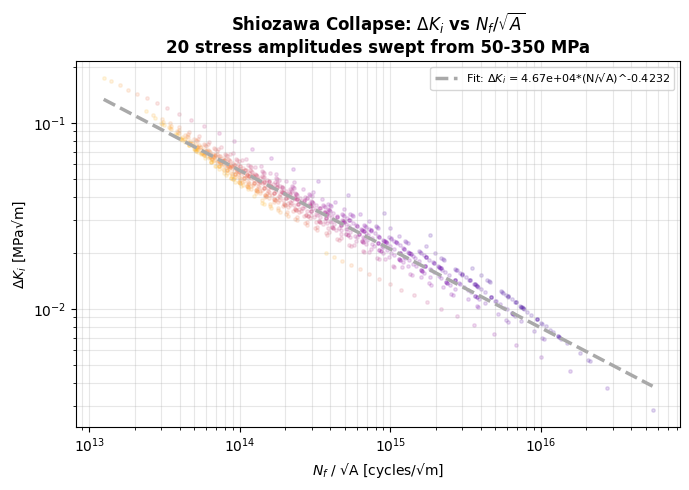

In [ ]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# empty lists to store info
dKi_all = []
Nnorm_all = []

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(sqrt_A_m, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(sqrt_A_m, ds_i, Y)
    sqrt_A_i = sqrt_A_m

    Nnorm_i = (Nf_i / sqrt_A_i)           # normalized life, N/√A [cycles/√m]
    
    # store results
    dKi_all.append(dKi_i)
    Nnorm_all.append(Nnorm_i)

    # plots
    ax1.scatter(sqrt_A_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )

all_dKi = np.concatenate(dKi_all) 
all_Nnorm = np.concatenate(Nnorm_all)

log_x = np.log10(all_Nnorm)
log_y = np.log10(all_dKi)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(log_x.min(), log_x.max(), 300)
y_line = 10**intercept * x_line**slope

print(f"Shiozawa collapse fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# show fitted line from log-log fit on shiozawa collapse plot
ax2.plot(x_line, y_line, color="darkgray", linewidth=2.5, linestyle="--",
         label=f"Fit: $\\Delta K_i$ = {10**intercept:.2e}*(N/√A)^{slope:.4f}")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (√m^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f/\\sqrt{A}$\n"
     "20 stress amplitudes swept from 50-350 MPa"),
]:

    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.grid(alpha=0.3, which="both")

ax2.legend(fontsize=8, ncol=2, #title="Stress Amplitude"
           )
# save and show
fig1.tight_layout(); fig1.savefig("database_ti_graphs/A_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("database_ti_graphs/A_shiozawa_collapse.png",  dpi=150)
plt.show()

Across a dense sweep of stress amplitudes, the Shiozawa collapse is visible.

# 2. Defect Size Distribution
Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

This section will present a parametric PDF fit to measured defect sizes

## 2.2. Defect Size Distribution
Since Zhou reports √A, this data is treated as the **critical defect**.

The distribution of the defects is fitted and plotted.

### 2.2.a. Distribution Parameters
Since the Zhou dataset directly reports the critical defect size √A, the distribution parameters are estimated **directly from the experimental √A values** rather than from a VED-based synthetic model.

In [ ]:
# distribution parameters fitted directly from experimental √area data
sqrt_A_um_valid = sqrt_A_um[np.isfinite(sqrt_A_um) & (sqrt_A_um > 0)]

# lognormal parameters from measured √area [μm]
sigma_ln, loc_ln, scale_ln = lognorm.fit(sqrt_A_um_valid, floc=0)

mu_ln = np.log(scale_ln)
median_sqrt_A = np.exp(mu_ln)

print("Experimental defect-size distribution parameters:")
print(f"  mu_ln = {mu_ln:.4f}")
print(f"  sigma_ln = {sigma_ln:.4f}")
print(f"  median √A = {median_sqrt_A:.2f} μm")

NameError: name 'sqrt_A_um' is not defined

### 2.2.b. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [ ]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
data_m = sqrt_A_m       # data is sqrt_A in meters

candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [ ]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(data_m, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.1870      0.2161
Weibull               0.1047      0.8639
Gumbel                0.0884      0.9569

Best fit: Gumbel (KS = 0.0884, p = 0.9569)
Parameters: loc = 4.062e-05, scale = 2.872e-05


### 2.2.c. Defect Size Histogram & PDF

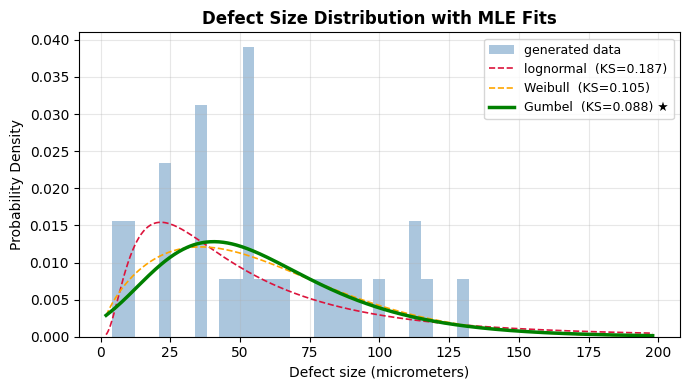

In [ ]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = data_m * 1e6   # convert data to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(data_m.min() * 0.5, data_m.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("database_ti_graphs/2_defect_pdf.png", dpi=150)
plt.show()

**Gumbel** is the best fit for this data; whereas, it was assumed lognormal was the best when generating synthetic data.